In [23]:
%load_ext autoreload
%autoreload 2
from dataloader import DataLoader
from model import LinearRegressionModel
import numpy as np
import pandas as pd
import os, sys
import matplotlib.pyplot as plt
import seaborn as sns

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
# Initialization
data_dict = {'train': os.path.join('Dataset', 'train.csv'),
             'test': os.path.join('Dataset', 'test.csv'),
             'ideal': os.path.join('Dataset', 'ideal.csv'), }
loader = DataLoader(db_name="data.db")
# get train, test and ideal set
train_df, test_df, ideal_df = loader.store_data_into_db(dict_csv=data_dict)

Table 'training_tb' exists.
Table 'test_tb' exists.
Table 'ideal_tb' exists.


Calculating ideal set: 100%|██████████| 50/50 [00:00<00:00, 17921.31it/s]

Min value and min arg:  51.06278169329284 41
Best ideal set is y42 with values 51.06278169329284
{'set_1': {'best_ideal_set': 'y42', 'error': 51.06278169329284}}


In [27]:
# x_arr = train_df['x'].values
# y1_arr = train_df['y1'].values
# y2_arr = train_df['y2'].values
# y3_arr = train_df['y3'].values
# y4_arr = train_df['y4'].values

In [45]:
ideal_dict = {}
reg_model = LinearRegressionModel(train_df, test_df, ideal_df)
for i in range(1,5):
    best_ideal_dict = reg_model.choose_y_ideal(set_id=i)
    ideal_dict.update(best_ideal_dict)
ideal_dict

Calculating ideal set: 100%|██████████| 50/50 [00:00<00:00, 19150.32it/s]


Min value and min arg:  51.06278169329284 41
Best ideal set is y42 with values 51.06278169329284


Calculating ideal set: 100%|██████████| 50/50 [00:00<00:00, 20106.92it/s]


Min value and min arg:  48.99185159761221 40
Best ideal set is y41 with values 48.99185159761221


Calculating ideal set: 100%|██████████| 50/50 [00:00<00:00, 25194.04it/s]


Min value and min arg:  0.008431092973386822 10
Best ideal set is y11 with values 0.008431092973386822


Calculating ideal set: 100%|██████████| 50/50 [00:00<00:00, 25245.60it/s]

Min value and min arg:  0.32555545670531044 43
Best ideal set is y44 with values 0.32555545670531044


{'set_1': {'best_ideal_set': 'y42', 'error': 51.06278169329284},
 'set_2': {'best_ideal_set': 'y41', 'error': 48.99185159761221},
 'set_3': {'best_ideal_set': 'y11', 'error': 0.008431092973386822},
 'set_4': {'best_ideal_set': 'y44', 'error': 0.32555545670531044}}

Calculating ideal set: 100%|██████████| 50/50 [00:00<00:00, 18837.26it/s]

Min value and min arg:  0.008431092973386822 10
Best ideal set is y11 with values 0.008431092973386822
{'set_3': {'best_ideal_set': 'y11', 'error': 0.008431092973386822}}


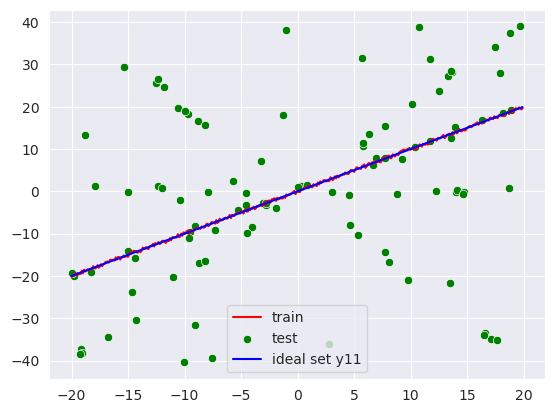

In [43]:
#Build model
set_id = 3

# Extract X y
X_train, y_train = reg_model.extract_x_y(is_train=True, set_id=set_id)
X_test, y_test = reg_model.extract_x_y(is_train=False, set_id=set_id)

# Get y ideal
y_chosen = ideal_dict[f'set_{set_id}']['best_ideal_set']
y_ideal_set = ideal_df[y_chosen].values

fig, ax = plt.subplots()
# Create plot for 3 set
sns.lineplot(x=X_train, y=y_train, ax=ax,color='red',label='train')
sns.scatterplot(x=X_test, y =y_test,ax=ax,color='green',label='test')
sns.lineplot(x=X_train,
             y=y_ideal_set,
             ax=ax,
             color='blue',
             label=f'ideal set {ideal_dict[f'set_{set_id}']['best_ideal_set']}')
plt.show()